## **Replicação de Artigos**

In [ ]:
# Importando Bibliotecas
import os
import pandas as pd
import re

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Importando Modelos
from src.models.models_artigos.full_hrnet.full_hrnet import FullHRNet
from src.models.models_artigos.full_hrnet.full_hrnet_pretrained import FullHRNet_ImageNet

# Importar sua classe existente
from src.vfss_dataset import VFSSImageDataset

from src.split_data import split_data_k_fold
from src.utils import (plot_image_with_mask,
                       get_script_relative_path,
                       get_project_root_directory,
                       get_corners_from_angle,
                       clahe,
                       modify_input,
                       load_points,
                       custom_collate_fn,
                       set_seed,
                       avalia_status_GPU,
                       resolve_dataframe_path)

# Importando classes/funções - Podar imports que não são chamados aqui.
from src.training.config import TrainingConfig
from src.training.loss import (LossCalculator,
                               FocalMSELoss,
                               FocalMSEMaskedLoss)
from src.training.holdout import holdout
from src.training.cross_validation import cross_validate
from src.evalutation.inference import display_inference

set_seed(42)

## **Full HR-Net**

### **Configuração**

In [ ]:
# Parametros Básicos Iniciais
width = 32

# Transformações
output_dim = (448, 448)

transform_augmentation_offline = A.Compose([
        A.PixelDropout(dropout_prob = 0.01, p = 0.5),
        A.ShiftScaleRotate(shift_limit = 0.06, scale_limit = 0.1, rotate_limit = 10, p = 0.5),
        A.Perspective(scale=(0.01, 0.02), keep_size=True, fit_output=False, p=0.5),
        A.CropAndPad(px=(-30, 30), p=0.5),
        A.AdvancedBlur(blur_limit= (3, 15), rotate_limit= (-90, 90), beta_limit= (0.5, 8.0), noise_limit= (0.9, 1.1), p= 0.5),
        A.RandomBrightnessContrast(p=0.5),                      # Brilho de Contraste
        A.GaussNoise(var_limit=(00.0, 100.0), mean=0, p=0.5),   # Ruído Gaussiano
        A.Resize(output_dim[0], output_dim[1])
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
    )

transform_puro = A.Compose([A.Resize(output_dim[0], output_dim[1]),
                       ToTensorV2()],
                      keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

# Configuração
config_fullhrnet = TrainingConfig(
         path_dataframe = "data/metadados/video_frame_metadata.csv",
         model_class    = FullHRNet_ImageNet,
         model_kwargs = {"num_keypoints": 2,
                         "width": width,
                         "pretrained_path": f"data/model_weights/FullHRNet_ImageNet/model_hrnet_w{width}_imagenet.pth"
                         },
         test_size      = 0.2,
         n_folds        = 5,
         dataset_class  = VFSSImageDataset,
         sigma_heatmap  = 20,

         # Hiperparâmetros do Modelo
         epochs             = 200,
         learning_rate      = 0.001,
         batch_size         = 8,
         patience           = 5,
         lr_patience        = 1e-10,
         optimizer          = torch.optim.Adam,
         optimizer_kwargs   = {},
         scheduler          = torch.optim.lr_scheduler.ReduceLROnPlateau,
         scheduler_kwargs   = {"mode":"min",
                               "factor":0.1,
                               "patience":3},

         # Offline Augmentation
         offline_augmentation    = True,
         transform_augmentation  = transform_augmentation_offline,
         augmentation_dir        = "data/frames_augmentation",
         n_aug                   = 5,

         # Funções e Transformações
         output_dim           = output_dim,
         modify_input_fn      = None, # modify_input,
         collate_fn           = custom_collate_fn,
         transform_train      = transform_puro,
         transform_validation = transform_puro,

         # Função de Loss
         criterion_roi       = nn.BCEWithLogitsLoss(),
         criterion_heatmap   = nn.MSELoss(),
         criterion_keypoints = None,
         weight_roi          = 0.0,
         weight_heatmap      = 1.0,
         weight_penalty      = 0.0,
         weight_keypoints    = 0.0,

         # Outros
         device          = "cuda" if torch.cuda.is_available() else "cpu",
         predict_roi     = False,
         width           = width
         )

# Avaliando Status do Uso da GPU
avalia_status_GPU()

Folds all: 92
Test: 23
Overall Dataset - Videos: 234 | Patients: 115 | Frames: 973 (100.0%)
Training + Validation Set - Videos: 192 | Patients: 92 | Frames: 795 (81.7%)
Test Set - Videos: 42 | Patients: 23 | Frames: 178 (18.3%)

Fold 1 - Videos: 41 | Patients: 19 | Frames: 174 (17.9%)
Fold 2 - Videos: 56 | Patients: 19 | Frames: 230 (23.6%)
Fold 3 - Videos: 40 | Patients: 18 | Frames: 168 (17.3%)
Fold 4 - Videos: 26 | Patients: 18 | Frames: 108 (11.1%)
Fold 5 - Videos: 29 | Patients: 18 | Frames: 115 (11.8%)


,split_name,n_videos,n_patients,n_frames,percentage_of_initial_frames,video_ids
0,fold_1,41,19,174,0.178828,"[101, 102, 103, 104, 105, 106, 107, 108, 109, ..."
1,fold_2,56,19,230,0.236382,"[129, 130, 131, 132, 136, 137, 138, 139, 140, ..."
2,fold_3,40,18,168,0.172662,"[122, 123, 125, 126, 127, 128, 152, 153, 154, ..."
3,fold_4,26,18,108,0.110997,"[10, 113, 114, 115, 116, 117, 118, 119, 120, 1..."
4,fold_5,29,18,115,0.118191,"[192, 193, 194, 195, 196, 197, 198, 199, 200, ..."
5,test_set,42,23,178,0.182939,"[100, 11, 13, 142, 143, 144, 145, 146, 147, 14..."



VERIFICAÇÃO DE GPU
PyTorch version: 2.2.2+cu121
CUDA disponível: True
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 2080 Ti
Número de GPUs: 1



### **Treino/Validação**

In [ ]:
# Treinamento do Modelo

# Holdout Training sem tunagem

results = holdout(
    df_train=pd.concat([config_fullhrnet.list_df_folds[j] for j in range(1,config_fullhrnet.n_folds)], ignore_index=True),
    df_val=config_fullhrnet.list_df_folds[0],
    config=config_fullhrnet,
)

Arquivos antigos de augmentation apagados!


Offline Augmentation - Processando em Paralelo: 100%|██████████| 621/621 [00:32<00:00, 18.90it/s]


HRNet 32 inicializada com 39 camadas da ImageNet.


Treinando: 100%|██████████| 389/389 [00:51<00:00,  7.56it/s]


Época 1/200
  Train Loss: 0.1860 | Val Loss: 0.0103
  Val Components - ROI: 0.0000, Heatmap: 0.0103, Penalty: 0.0105
✓ Melhor modelo salvo (val_loss: 0.0103)


...

Época 21/200
  Train Loss: 0.0004 | Val Loss: 0.0012
  Val Components - ROI: 0.0000, Heatmap: 0.0012, Penalty: 0.0031


Treinando: 100%|██████████| 389/389 [00:18<00:00, 20.89it/s]


Época 22/200
  Train Loss: 0.0004 | Val Loss: 0.0012
  Val Components - ROI: 0.0000, Heatmap: 0.0012, Penalty: 0.0022


Treinando: 100%|██████████| 389/389 [00:18<00:00, 20.79it/s]


Época 23/200
  Train Loss: 0.0004 | Val Loss: 0.0012
  Val Components - ROI: 0.0000, Heatmap: 0.0012, Penalty: 0.0029
Early stopping ativado na época 23
✓ Checkpoint carregado: epoch 17, val_loss: 0.0011

Loss Final: 0.0011

RESULTADOS FINAIS
Média dos Folds: 0.0011 ± 0.0000
Melhor Fold: 1 (Loss: 0.0011)


### **Teste**


INICIANDO AVALIAÇÃO NO CONJUNTO DE TESTE
HRNet 32 inicializada com 39 camadas da ImageNet.
✓ Modelo carregado: data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_32W\fold_1_best.pth
  Epoch: 17
  Val Loss: 0.0011

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:05<00:00, 29.67it/s]



GERANDO VISUALIZAÇÕES
✓ Gráfico salvo: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\loss_distributions.png


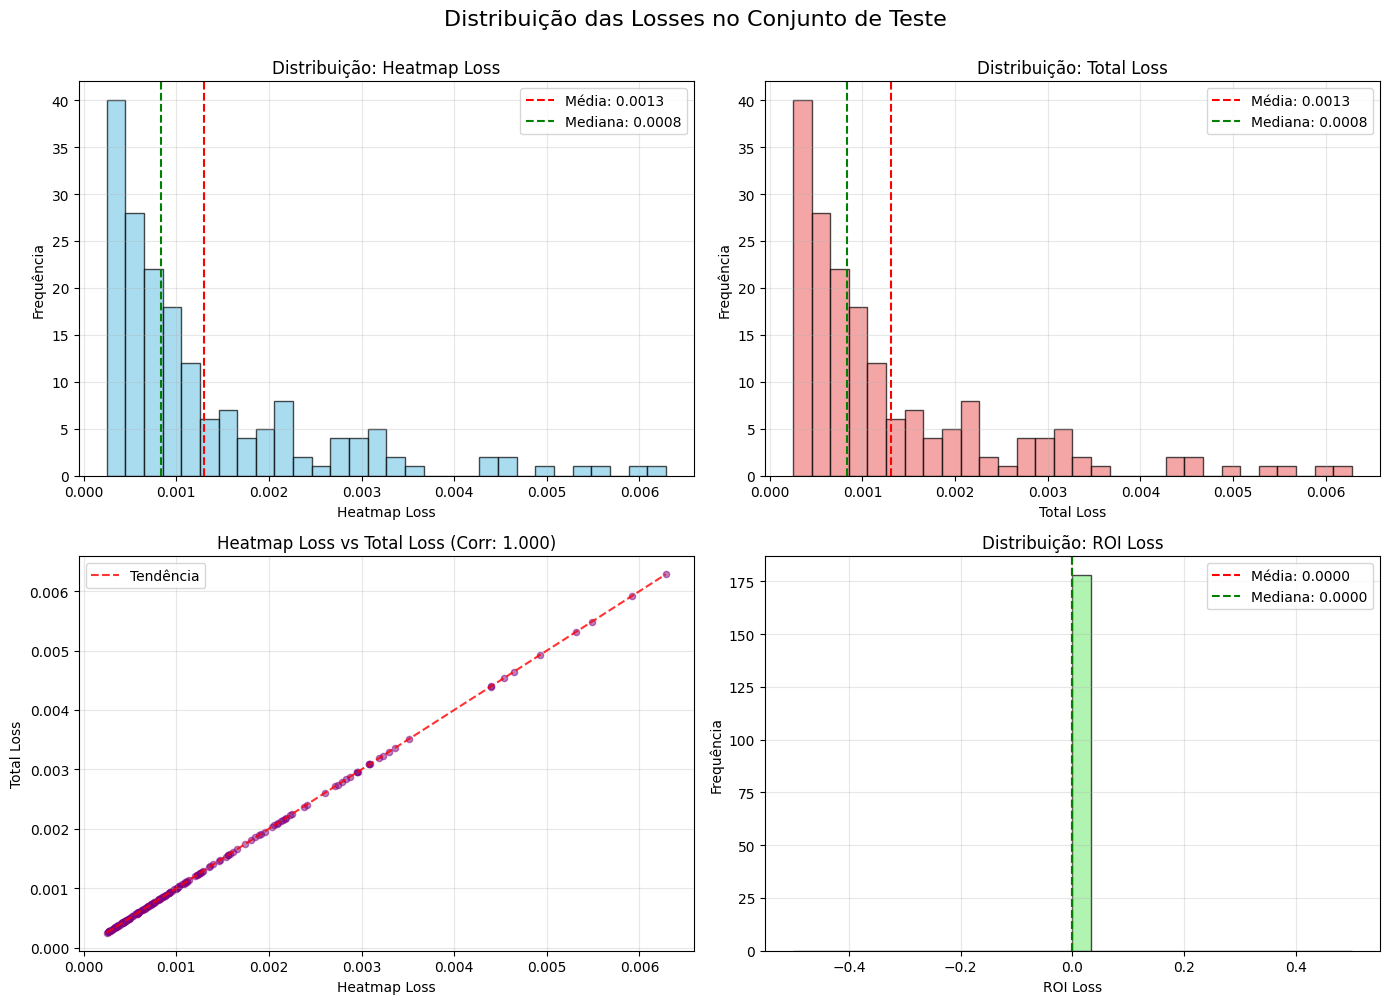

✓ Gráfico salvo: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\keypoint_analysis.png


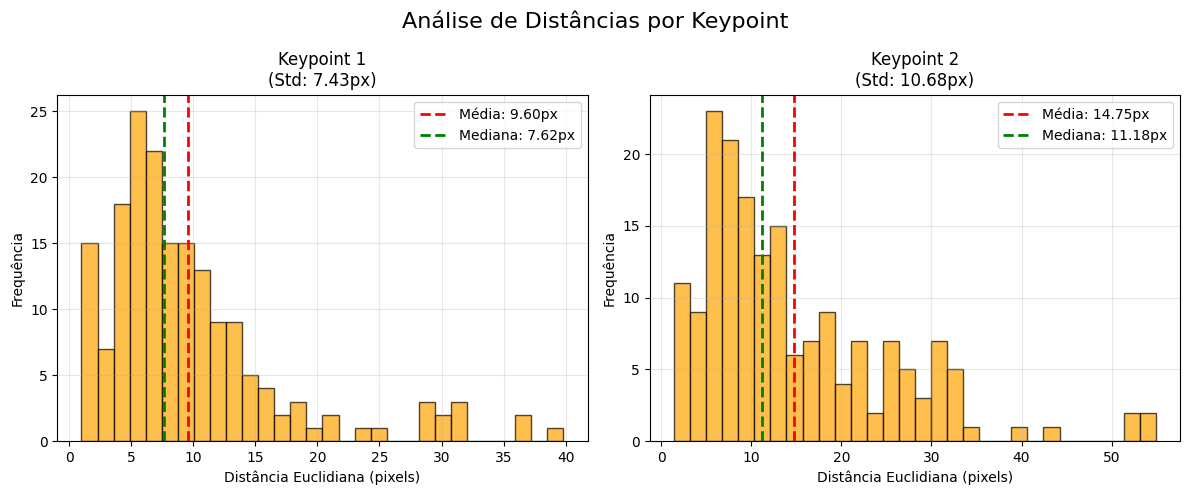


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\predictions_by_distance_keypoint1.png


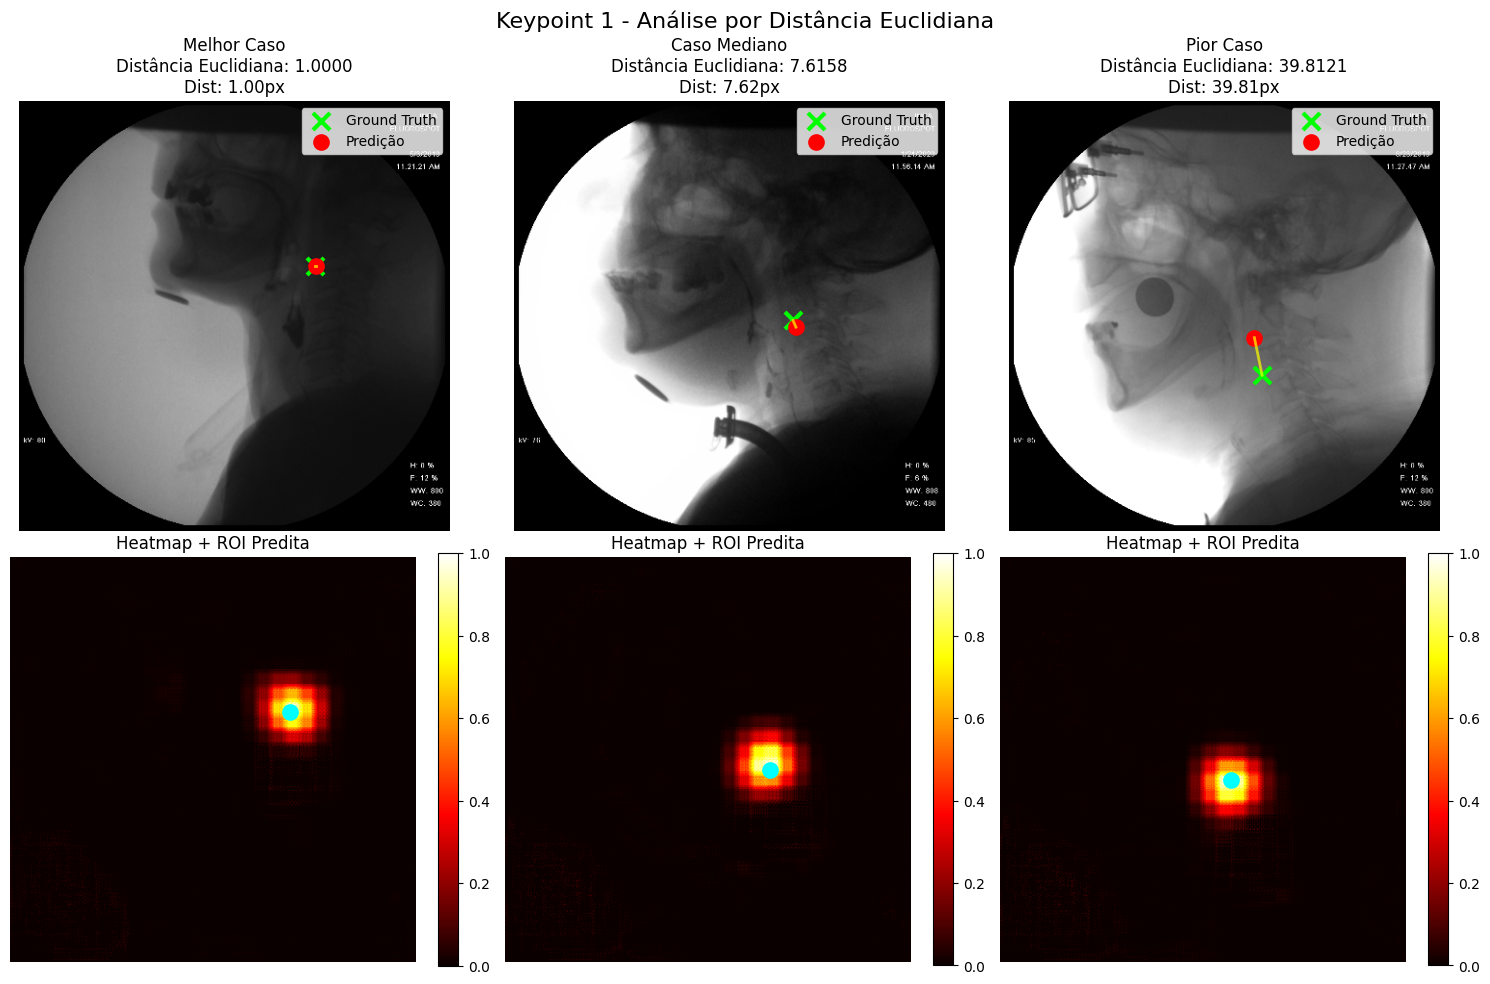


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\predictions_by_distance_keypoint2.png


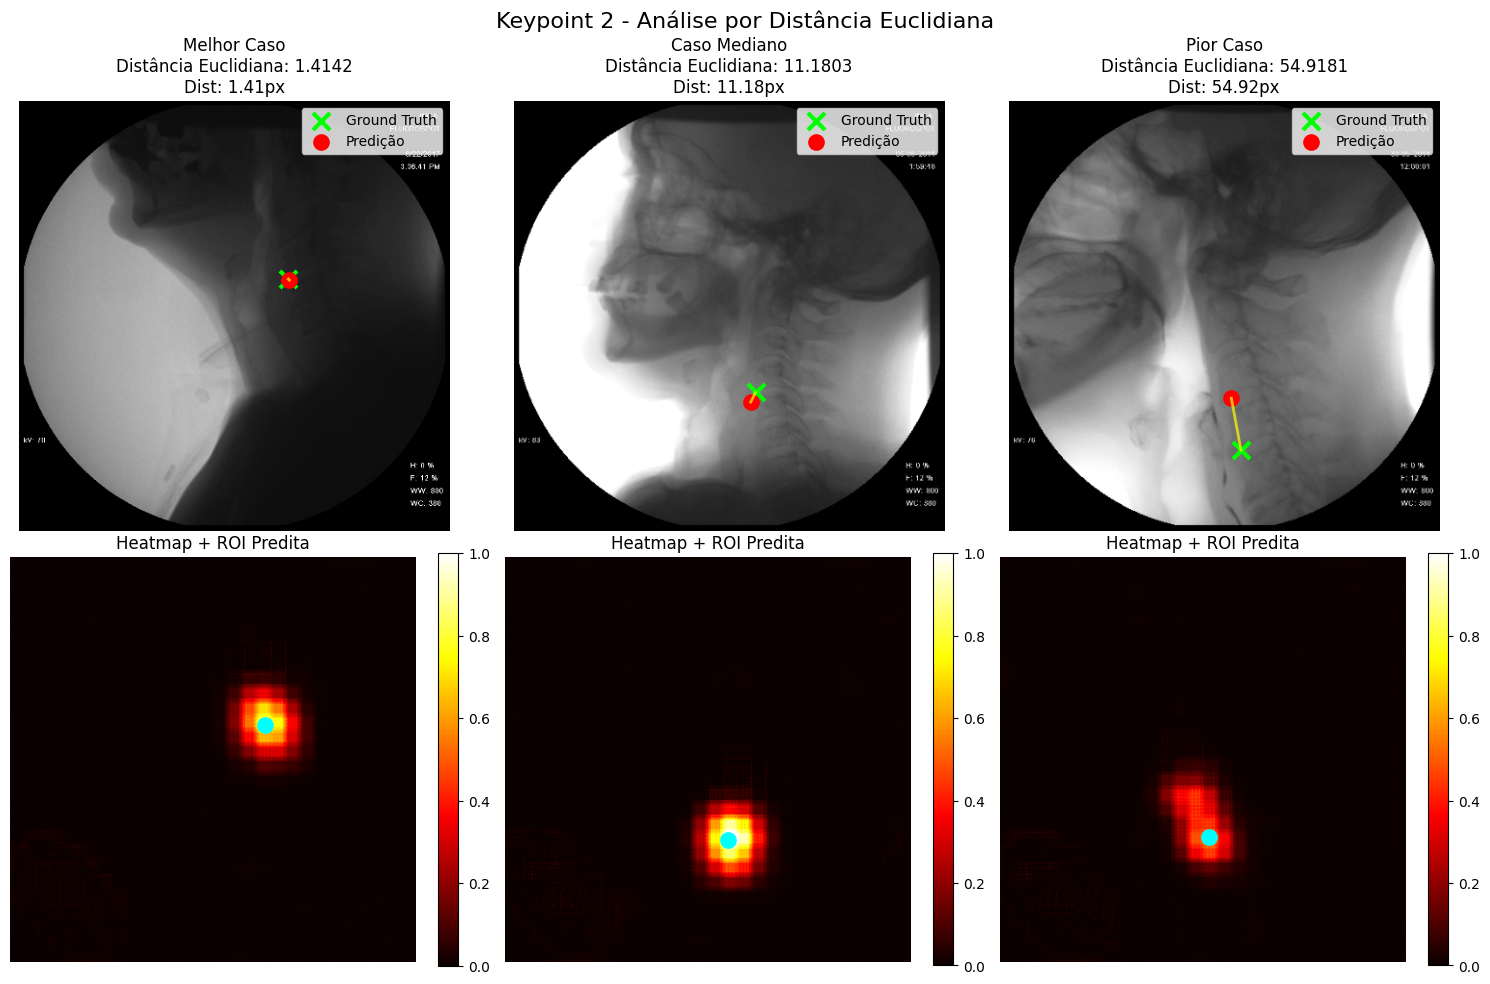


--- Visualizações para Keypoint 1 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\predictions_by_loss_keypoint1.png


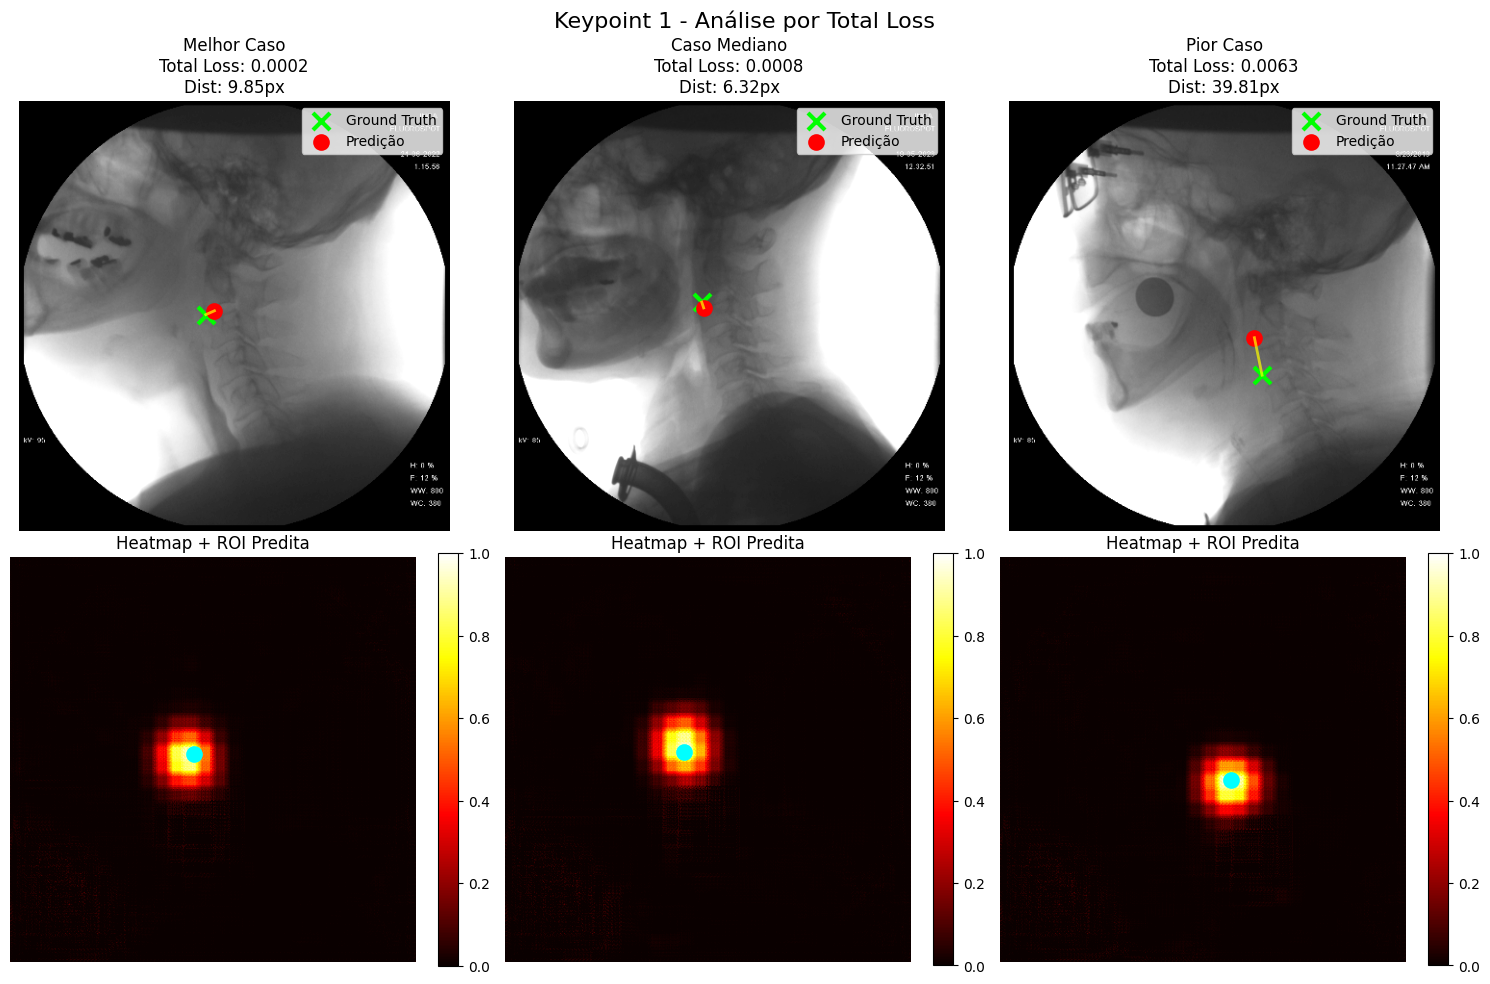


--- Visualizações para Keypoint 2 ---
✓ Figura salva: figs\FullHRNet_ImageNet\MSELoss_200ep_32W\fold1\predictions_by_loss_keypoint2.png


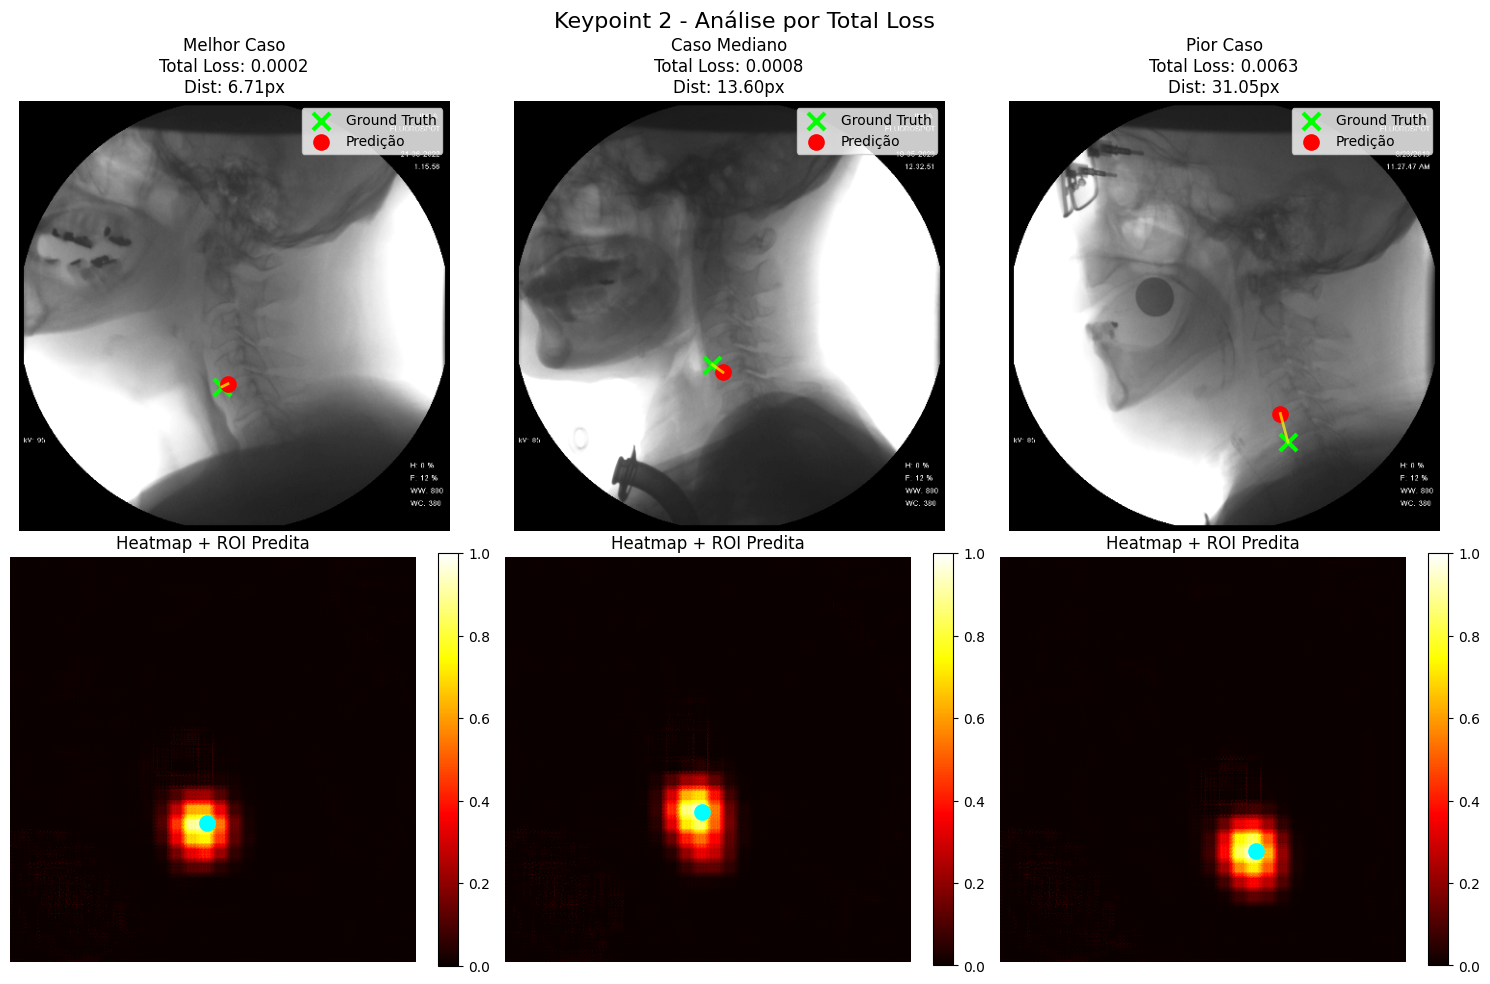

RELATÓRIO DE AVALIAÇÃO NO CONJUNTO DE TESTE

Número de amostras: 178

----------------------------------------------------------------------
LOSS TOTAL
----------------------------------------------------------------------
Média:    0.001304
Mediana:  0.000839
Std:      0.001202
Min:      0.000249
Max:      0.006285

----------------------------------------------------------------------
HEATMAP LOSS
----------------------------------------------------------------------
Média:    0.001304
Mediana:  0.000839
Std:      0.001202

----------------------------------------------------------------------
ROI LOSS
----------------------------------------------------------------------
Média:    0.000000
Mediana:  0.000000
Std:      0.000000

----------------------------------------------------------------------
KEYPOINT 1 - DISTÂNCIA EUCLIDIANA (pixels)
----------------------------------------------------------------------
Média:    9.60
Mediana:  7.62
Std:      7.43
Min:      1.00
Max:      39.8

c:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\.venv\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [ ]:
# Verificando Inferência no conjunto de Teste
path_config_fullhrnet = os.path.join("data\model_weights",config_fullhrnet.model_name,'config.pkl')
display_inference(path_config_fullhrnet)

## **ResNet**

### **Configuração**

In [ ]:
# Parametros Básicos Iniciais

# Transformações
output_dim = (448, 448)

transform_augmentation_offline =  A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(rotate=(-45, 45), shear=(-10, 10), p=1.0),
    A.Affine(scale=(0.75, 1.25), p=1.0),
    A.ColorJitter(brightness=(0.8, 1.2), contrast=0, saturation=0, hue=0, p=1.0),
    A.Resize(output_dim[0], output_dim[1])
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
    )

transform_puro = A.Compose([A.Resize(output_dim[0], output_dim[1]),
                       ToTensorV2()],
                      keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

# Configuração
config_resnet = TrainingConfig(
         path_dataframe = "data/metadados/video_frame_metadata.csv",
         model_class    = ResNet_ImageNet,
         model_kwargs = {"num_keypoints": 2,
                         },
         test_size      = 0.2,
         n_folds        = 5,
         dataset_class  = VFSSImageDataset,
         sigma_heatmap  = 20,

         # Hiperparâmetros do Modelo
         epochs             = 80,
         learning_rate      = 0.01,
         batch_size         = 8,
         patience           = 80,                    # Não usado
         lr_patience        = 1e-10,                 # Não usado
         optimizer          = torch.optim.SGD,
         optimizer_kwargs   = {"momentum": 0.9,
                               "weight_decay": 1e-4},
         scheduler          = torch.optim.lr_scheduler.ExponentialLR,
         scheduler_kwargs   = {"gamma": 0.95}

         # Offline Augmentation
         offline_augmentation    = True,
         transform_augmentation  = transform_augmentation_offline,
         augmentation_dir        = "data/frames_augmentation",
         n_aug                   = 1,

         # Funções e Transformações
         output_dim           = output_dim,
         modify_input_fn      = None,
         collate_fn           = custom_collate_fn,
         transform_train      = transform_puro,
         transform_validation = transform_puro,

         # Função de Loss
         criterion_roi       = nn.BCEWithLogitsLoss(),
         criterion_heatmap   = nn.MSELoss(),
         criterion_keypoints = None,
         weight_roi          = 0.0,
         weight_heatmap      = 0.5,
         weight_penalty      = 0.0,
         weight_keypoints    = 0.5,

         # Outros
         device          = "cuda" if torch.cuda.is_available() else "cpu",
         predict_roi     = False,
         width           = width
         )

# Avaliando Status do Uso da GPU
avalia_status_GPU()

### **Treino/Validação**

In [ ]:
# TREINO

# Holdout Training sem tunagem

results = holdout(
    df_train=pd.concat([config_resnet.list_df_folds[j] for j in range(1,config_resnet.n_folds)], ignore_index=True),
    df_val=config_resnet.list_df_folds[0],
    config=config_resnet,
)

### **Teste**

In [ ]:
# Verificando Inferência no conjunto de Teste
path_config_resnet = os.path.join("data\model_weights",config_resnet.model_name,'config.pkl')
display_inference(path_config_resnet)